# Baseline — comparação de candidatos

Reproduz, de forma independente e com visualizações, a comparação de modelos que embasa a
escolha documentada em [`docs/model_card.md`](../docs/model_card.md) e na seção
"Resultados" do README: uma **baseline ingênua** (`DummyClassifier`, sem aprender nada do
texto) contra os dois candidatos reais do pipeline de produção
(`src/triagem/model/train.py`), treinados e avaliados com o mesmo código que roda em
`make train` e na DAG do Airflow — não uma reimplementação paralela.

Os splits usam a mesma seed (`42`) e proporção (`validation_size=0.2`) do pipeline, para que
os números aqui sejam comparáveis aos publicados.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay

from triagem.config import get_settings
from triagem.data.download import download_dataset
from triagem.data.prepare import (
    CONDITION_NAMES,
    LABEL_COLUMN,
    TEXT_COLUMN,
    load_split,
    split_train_validation,
)
from triagem.model.evaluate import evaluate_model
from triagem.model.train import MODEL_TYPES, train_model

plt.rcParams["figure.dpi"] = 110
settings = get_settings()
paths = download_dataset(settings.data_dir / "raw")

frame = load_split(paths["train"])
treino, validacao = split_train_validation(
    frame, validation_size=settings.validation_size, seed=settings.random_seed
)
teste = load_split(paths["test"])

print(f"treino:     {len(treino)}")
print(f"validação:  {len(validacao)}")
print(f"teste:      {len(teste)}")

treino:     9240
validação:  2310
teste:      2888


## 1. Baseline ingênua

Duas estratégias de `DummyClassifier` como piso de referência — nenhuma delas olha o texto:

- **most_frequent**: sempre prevê a classe majoritária. É o piso que a acurácia bruta
  precisa vencer.
- **stratified**: sorteia a classe respeitando a proporção do treino. É o piso mais
  relevante para o f1-macro, a métrica de decisão do pipeline.

O corpus tem 5 classes: um classificador uniformemente aleatório teria f1-macro esperado
~0,20 — é a referência citada no model card.

In [2]:
baseline_scores: dict[str, dict[str, float]] = {}

for estrategia in ("most_frequent", "stratified"):
    dummy = DummyClassifier(strategy=estrategia, random_state=settings.random_seed)
    dummy.fit(treino[TEXT_COLUMN], treino[LABEL_COLUMN])
    metricas = evaluate_model(dummy, teste[TEXT_COLUMN], teste[LABEL_COLUMN], CONDITION_NAMES)
    baseline_scores[f"dummy_{estrategia}"] = metricas
    print(
        f"{estrategia:15s} accuracy={metricas['accuracy']:.4f}  f1_macro={metricas['f1_macro']:.4f}"
    )

most_frequent   accuracy=0.3328  f1_macro=0.0999
stratified      accuracy=0.2223  f1_macro=0.1878


## 2. Candidatos reais (mesmo código de `make train`)

In [3]:
candidate_scores: dict[str, dict[str, float]] = {}
pipelines = {}

for model_type in MODEL_TYPES:
    pipeline = train_model(
        treino[TEXT_COLUMN], treino[LABEL_COLUMN], model_type=model_type, seed=settings.random_seed
    )
    pipelines[model_type] = pipeline

    val_metrics = evaluate_model(
        pipeline, validacao[TEXT_COLUMN], validacao[LABEL_COLUMN], CONDITION_NAMES
    )
    test_metrics = evaluate_model(
        pipeline, teste[TEXT_COLUMN], teste[LABEL_COLUMN], CONDITION_NAMES
    )
    candidate_scores[model_type] = {"validation": val_metrics, "test": test_metrics}

    print(
        f"{model_type:20s} "
        f"f1_macro(val)={val_metrics['f1_macro']:.4f}  "
        f"f1_macro(teste)={test_metrics['f1_macro']:.4f}"
    )

random_forest        f1_macro(val)=0.5304  f1_macro(teste)=0.5350


logistic_regression  f1_macro(val)=0.5871  f1_macro(teste)=0.5802


## 3. Comparação — baseline vs. candidatos

In [4]:
resumo = pd.DataFrame(
    {
        "dummy_most_frequent (teste)": {
            "accuracy": baseline_scores["dummy_most_frequent"]["accuracy"],
            "f1_macro": baseline_scores["dummy_most_frequent"]["f1_macro"],
        },
        "dummy_stratified (teste)": {
            "accuracy": baseline_scores["dummy_stratified"]["accuracy"],
            "f1_macro": baseline_scores["dummy_stratified"]["f1_macro"],
        },
        **{
            f"{nome} (validação)": {
                "accuracy": scores["validation"]["accuracy"],
                "f1_macro": scores["validation"]["f1_macro"],
            }
            for nome, scores in candidate_scores.items()
        },
        **{
            f"{nome} (teste)": {
                "accuracy": scores["test"]["accuracy"],
                "f1_macro": scores["test"]["f1_macro"],
            }
            for nome, scores in candidate_scores.items()
        },
    }
).T.round(4)
resumo

,accuracy,f1_macro
dummy_most_frequent (teste),0.3328,0.0999
dummy_stratified (teste),0.2223,0.1878
random_forest (validação),0.5364,0.5304
logistic_regression (validação),0.5857,0.5871
random_forest (teste),0.5374,0.5350
logistic_regression (teste),0.5779,0.5802


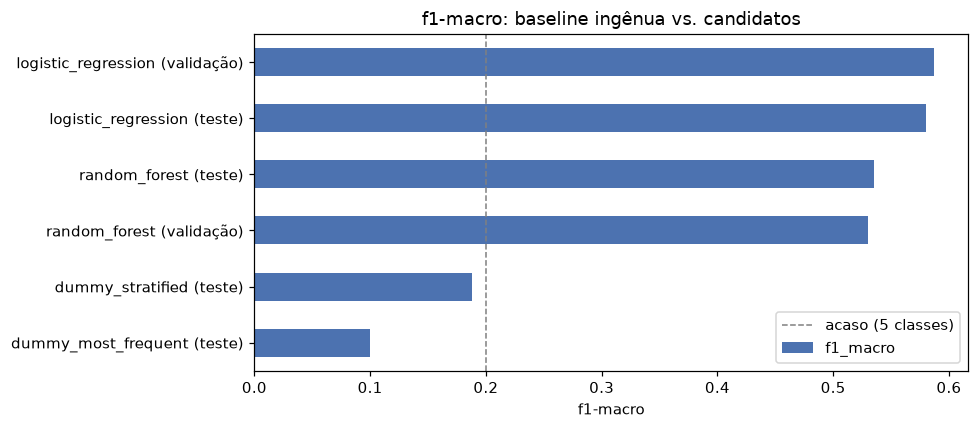

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
resumo["f1_macro"].sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.axvline(0.2, color="gray", linestyle="--", linewidth=1, label="acaso (5 classes)")
ax.set_xlabel("f1-macro")
ax.set_title("f1-macro: baseline ingênua vs. candidatos")
ax.legend()
plt.tight_layout()
plt.show()

Os dois candidatos batem folgadamente as duas baselines ingênuas — o texto carrega sinal
real, não é ruído que o modelo está memorizando. Entre os candidatos, a diferença de
f1-macro reproduz (dentro da variação de terceira casa decimal já documentada no README,
oriunda do solver `lbfgs`) o resultado publicado: **Regressão Logística** vence o
**Random Forest** na mesma vetorização TF-IDF.

## 4. Matriz de confusão do campeão

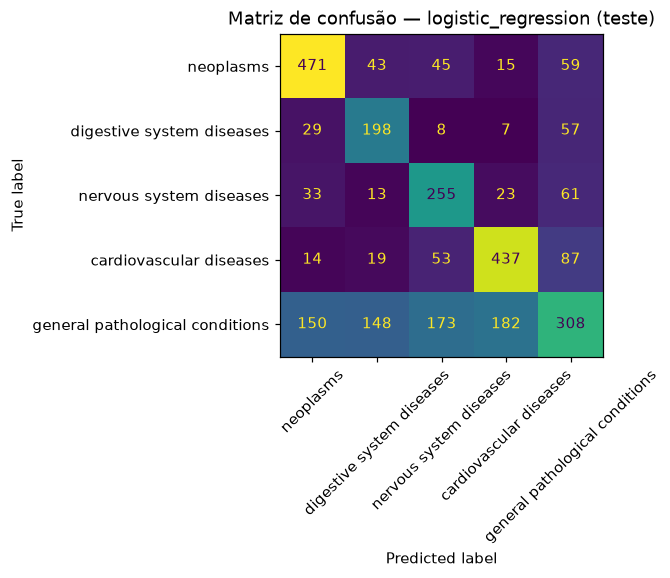

In [6]:
campeao = "logistic_regression"
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    pipelines[campeao],
    teste[TEXT_COLUMN],
    teste[LABEL_COLUMN],
    display_labels=[CONDITION_NAMES[i] for i in sorted(CONDITION_NAMES)],
    xticks_rotation=45,
    ax=ax,
    colorbar=False,
)
ax.set_title(f"Matriz de confusão — {campeao} (teste)")
plt.tight_layout()
plt.show()

A confusão concentra-se em `general pathological conditions` — a classe "guarda-chuva" que
o model card já sinaliza como teto do problema (recall mais baixo, se sobrepõe
semanticamente às outras quatro), não como defeito de ajuste do modelo.

Parte desse teto tem uma causa mais concreta que "sobreposição semântica": a EDA
([`01_eda.ipynb`](01_eda.ipynb), seção "Duplicatas e ambiguidade de rótulo") mede ~26% dos
textos únicos do corpus repetidos sob rótulos diferentes, o que limita a acurácia máxima
possível a ~78% para qualquer classificador baseado só no texto — o f1-macro do campeão
(~0,58) precisa ser lido contra esse teto, não contra 1,0.

## Conclusões

- Ambos os candidatos superam com folga as baselines ingênuas (`DummyClassifier`) e o piso
  teórico do acaso (0,20) — o ganho do modelo vem do texto, não de acidente estatístico.
- A Regressão Logística reproduz aqui a vantagem já publicada no README/model card sobre o
  Random Forest, na mesma vetorização TF-IDF.
- O erro do campeão concentra-se numa única classe semanticamente sobreposta às demais, não
  distribuído — reforça a leitura do model card de que é um teto do problema, não um ponto
  de ajuste fácil.
- Números completos de latência e tamanho de artefato (que também pesaram na escolha) estão
  no [model card](../docs/model_card.md) e não são reproduzidos aqui — este notebook cobre
  só a métrica de qualidade preditiva.